# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

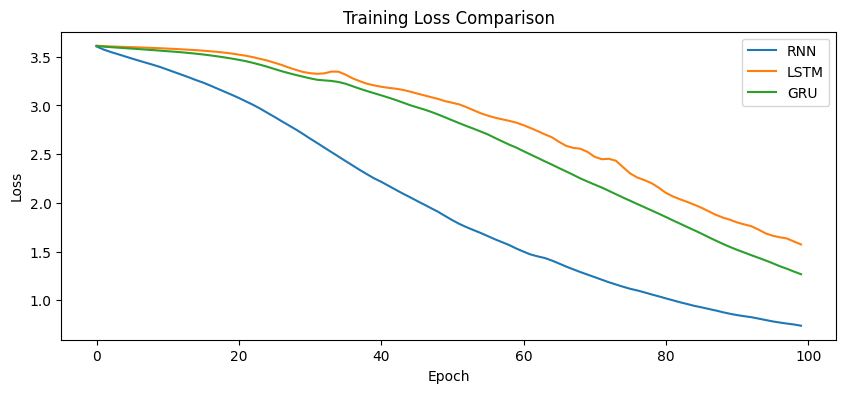

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning learning is artificial intelligence intelligence
GRU : deep learning models can generate meaningful meaningful


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## Beginner Tasks Implementation

Task 1: Replace corpus with your own paragraph

In [10]:
custom_corpus = '''
data science is an interdisciplinary field
machine learning algorithms learn from data
deep neural networks excel at complex tasks
natural language processing deals with text data
computer vision interprets images and video
artificial intelligence is the future
'''
print(custom_corpus)


data science is an interdisciplinary field
machine learning algorithms learn from data
deep neural networks excel at complex tasks
natural language processing deals with text data
computer vision interprets images and video
artificial intelligence is the future



In [11]:
custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts([custom_corpus])

custom_total_words = len(custom_tokenizer.word_index) + 1
print("Custom Vocabulary size:", custom_total_words)

custom_input_sequences = []
for line in custom_corpus.split('\n'):
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        custom_input_sequences.append(n_gram_seq)

custom_max_len = max(len(seq) for seq in custom_input_sequences)
custom_input_sequences = pad_sequences(custom_input_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_input_sequences[:, :-1]
y_custom = custom_input_sequences[:, -1]

print("X_custom shape:", X_custom.shape)
print("y_custom shape:", y_custom.shape)

Custom Vocabulary size: 35
X_custom shape: (31, 6)
y_custom shape: (31,)


Tasks 2, 3, 4: Increase embedding dimension, epochs, and hidden units

Define and train new models with the following parameters:
- Embedding dimension: `64`
- Hidden units: `128`
- Epochs: `200`

These models will be trained on the `custom_corpus`.

In [12]:
embedding_dim_tuned = 64
hidden_units_tuned = 128
epochs_tuned = 200

print(f"Training models with Embedding: {embedding_dim_tuned}, Hidden Units: {hidden_units_tuned}, Epochs: {epochs_tuned}")

rnn_model_tuned = Sequential([
    Embedding(custom_total_words, embedding_dim_tuned, input_length=custom_max_len-1),
    SimpleRNN(hidden_units_tuned),
    Dense(custom_total_words, activation='softmax')
])

rnn_model_tuned.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

rnn_history_tuned = rnn_model_tuned.fit(X_custom, y_custom, epochs=epochs_tuned, verbose=0)
print("Vanilla RNN (Tuned) training completed")

lstm_model_tuned = Sequential([
    Embedding(custom_total_words, embedding_dim_tuned, input_length=custom_max_len-1),
    LSTM(hidden_units_tuned),
    Dense(custom_total_words, activation='softmax')
])

lstm_model_tuned.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

lstm_history_tuned = lstm_model_tuned.fit(X_custom, y_custom, epochs=epochs_tuned, verbose=0)
print("LSTM (Tuned) training completed")

gru_model_tuned = Sequential([
    Embedding(custom_total_words, embedding_dim_tuned, input_length=custom_max_len-1),
    GRU(hidden_units_tuned),
    Dense(custom_total_words, activation='softmax')
])

gru_model_tuned.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

gru_history_tuned = gru_model_tuned.fit(X_custom, y_custom, epochs=epochs_tuned, verbose=0)
print("GRU (Tuned) training completed")

Training models with Embedding: 64, Hidden Units: 128, Epochs: 200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN (Tuned) training completed
LSTM (Tuned) training completed
GRU (Tuned) training completed


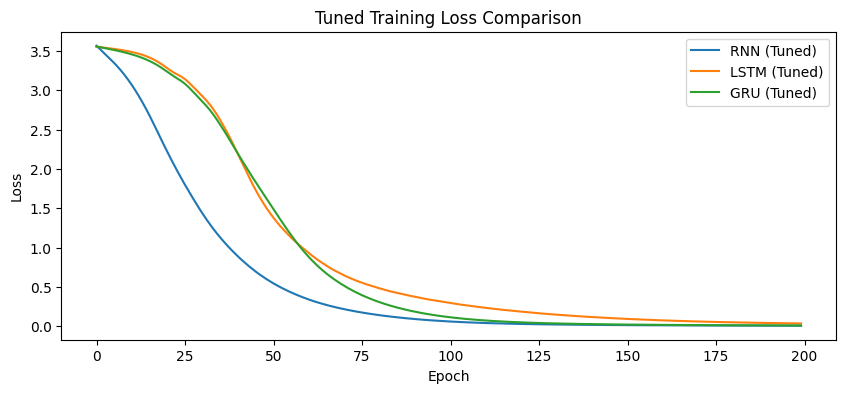

In [13]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_tuned.history['loss'], label='RNN (Tuned)')
plt.plot(lstm_history_tuned.history['loss'], label='LSTM (Tuned)')
plt.plot(gru_history_tuned.history['loss'], label='GRU (Tuned)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tuned Training Loss Comparison")
plt.legend()
plt.show()

Task 5: Generate 10 words instead of 5

Use the newly trained models to generate 10 words from a seed text.

In [14]:
# Helper function to generate text
def generate_text_tuned(model, seed_text, next_words, tokenizer_obj, max_sequence_length):
    for _ in range(next_words):
        token_list = tokenizer_obj.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_length-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer_obj.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break
        if output_word == "": # Handle cases where prediction is outside known vocab
            output_word = "<unk>"
        seed_text += " " + output_word
    return seed_text

print("RNN (Tuned) :", generate_text_tuned(rnn_model_tuned, "data science", 10, custom_tokenizer, custom_max_len))
print("LSTM (Tuned):", generate_text_tuned(lstm_model_tuned, "data science", 10, custom_tokenizer, custom_max_len))
print("GRU (Tuned) :", generate_text_tuned(gru_model_tuned, "data science", 10, custom_tokenizer, custom_max_len))

RNN (Tuned) : data science is an interdisciplinary field data tasks data data interdisciplinary field
LSTM (Tuned): data science is an interdisciplinary field field tasks tasks tasks tasks data
GRU (Tuned) : data science is an interdisciplinary field field field tasks tasks data data


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**